# ChickPoo Final Training Pipeline

Notebook final untuk dua model utama:
1. **Object Validation Model**: `chicken_feces` vs `not_chicken_feces`
2. **Disease Classification Model**: `cocci`, `healthy`, `ncd`, `salmo`

Pipeline sudah mencakup split train/validation/test, balancing train, augmentasi, model benchmarking, hyperparameter tuning ringan, fine-tuning, evaluasi, dan penyimpanan model terbaik.

In [1]:
# =========================================================
# 0. USER CONFIG: ISI / CEK 2 PATH DATASET DI SINI
# =========================================================
CHICKPOO_DATASET_DIR = "/kaggle/input/datasets/baihaqyel/chicpoodataset"
NON_FECES_DATASET_DIR = "/kaggle/input/datasets/baihaqyel/bukanfeses"

# =========================================================
# 1. GLOBAL CONFIG
# =========================================================
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

# Efisiensi training di T4/P100
USE_MIXED_PRECISION = True

# Split ratio
TEST_SIZE = 0.15
VAL_SIZE = 0.15

# Training budget. Naikkan kalau ingin hasil lebih maksimal.
BASELINE_EPOCHS = 8
TUNING_EPOCHS = 8
FINE_TUNE_EPOCHS = 6

# Batasi train per kelas agar training tetap efisien. None = tanpa cap.
MAX_OBJECT_TRAIN_PER_CLASS = 6000
MAX_DISEASE_TRAIN_PER_CLASS = None

# Model trials: pilih jumlah percobaan transfer learning.
RUN_SIMPLE_CNN_BASELINE = True
RUN_TRANSFER_TUNING = True
RUN_FINE_TUNING = True

OUTPUT_DIR = "/kaggle/working/chickpoo_final_outputs"


In [2]:
# =========================================================
# 2. IMPORTS & SETUP
# =========================================================
import os
import json
import shutil
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

if USE_MIXED_PRECISION:
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision aktif.")
    except Exception as e:
        print("Mixed precision tidak aktif:", e)

AUTOTUNE = tf.data.AUTOTUNE
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

for sub in [
    "models/object_validation/all_models",
    "models/disease_classification/all_models",
    "models/best_models",
    "weights/object_validation",
    "weights/disease_classification",
    "reports/object_validation",
    "reports/disease_classification",
    "plots/object_validation",
    "plots/disease_classification",
    "metadata",
]:
    Path(OUTPUT_DIR, sub).mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Output dir:", OUTPUT_DIR)


Mixed precision aktif.
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Output dir: /kaggle/working/chickpoo_final_outputs


## Utility Functions

In [3]:
# =========================================================
# 3. UTILITY FUNCTIONS
# =========================================================
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

OBJECT_CLASSES = ["not_chicken_feces", "chicken_feces"]
DISEASE_CLASSES = ["cocci", "healthy", "ncd", "salmo"]


def list_images(folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {folder}")
    paths = []
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
            paths.append(str(p))
    return sorted(paths)


def build_object_dataframe(chickpoo_dir, non_feces_dir):
    rows = []
    chickpoo_dir = Path(chickpoo_dir)
    for cls in DISEASE_CLASSES:
        cls_dir = chickpoo_dir / cls
        for path in list_images(cls_dir):
            rows.append({"filepath": path, "label": "chicken_feces"})
    for path in list_images(non_feces_dir):
        rows.append({"filepath": path, "label": "not_chicken_feces"})
    df = pd.DataFrame(rows).drop_duplicates("filepath").reset_index(drop=True)
    return df


def build_disease_dataframe(chickpoo_dir):
    rows = []
    chickpoo_dir = Path(chickpoo_dir)
    for cls in DISEASE_CLASSES:
        cls_dir = chickpoo_dir / cls
        for path in list_images(cls_dir):
            rows.append({"filepath": path, "label": cls})
    df = pd.DataFrame(rows).drop_duplicates("filepath").reset_index(drop=True)
    return df


def stratified_split(df, label_col="label", val_size=VAL_SIZE, test_size=TEST_SIZE, seed=SEED):
    temp_size = val_size + test_size
    train_df, temp_df = train_test_split(
        df,
        test_size=temp_size,
        stratify=df[label_col],
        random_state=seed,
    )
    relative_test_size = test_size / temp_size
    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_size,
        stratify=temp_df[label_col],
        random_state=seed,
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def balance_train_dataframe(df, label_col="label", max_per_class=None, seed=SEED):
    counts = df[label_col].value_counts()
    target = counts.max()
    if max_per_class is not None:
        target = min(target, int(max_per_class))
    parts = []
    for label, group in df.groupby(label_col):
        if len(group) >= target:
            sampled = group.sample(n=target, replace=False, random_state=seed)
        else:
            sampled = group.sample(n=target, replace=True, random_state=seed)
        parts.append(sampled)
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


def encode_labels(df, class_names):
    mapping = {name: idx for idx, name in enumerate(class_names)}
    return df["label"].map(mapping).astype("int32").values


def load_image(path, label, task="multiclass"):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")
    img = tf.cast(img, tf.float32)
    if task == "binary":
        label = tf.cast(label, tf.float32)
    else:
        label = tf.cast(label, tf.int32)
    return img, label


def make_dataset(paths, labels, task="multiclass", shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 4096), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_image(p, y, task=task), num_parallel_calls=AUTOTUNE)
    ds = ds.apply(tf.data.experimental.ignore_errors())
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


def get_augmentation(strength="medium"):
    if strength == "light":
        return models.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.04),
            layers.RandomZoom(0.06),
        ], name="augmentation_light")
    if strength == "strong":
        return models.Sequential([
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.12),
            layers.RandomTranslation(0.08, 0.08),
            layers.RandomZoom(0.18),
            layers.RandomContrast(0.18),
        ], name="augmentation_strong")
    return models.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.08),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.12),
    ], name="augmentation_medium")


def add_preprocessing(x, backbone_key):
    if backbone_key in ["mobilenetv2", "resnet50v2"]:
        return layers.Rescaling(scale=1.0 / 127.5, offset=-1.0, name="preprocess_minus1_to_1")(x)
    if backbone_key == "simple_cnn":
        return layers.Rescaling(1.0 / 255.0, name="preprocess_0_to_1")(x)
    return x


def get_backbone(backbone_key):
    if backbone_key == "mobilenetv2":
        return tf.keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
        )
    if backbone_key == "resnet50v2":
        return tf.keras.applications.ResNet50V2(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
        )
    if backbone_key == "efficientnetb0":
        return tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
        )
    raise ValueError(f"Backbone tidak dikenal: {backbone_key}")


def get_callbacks(weights_path, patience=3):
    return [
        ModelCheckpoint(
            filepath=weights_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=0,
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.35,
            patience=max(1, patience // 2),
            min_lr=1e-7,
            verbose=1,
        ),
    ]


def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


def plot_confusion_matrix(cm, labels, title, path):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## Model Builders

In [4]:
# =========================================================
# 4. MODEL BUILDERS
# =========================================================
def build_simple_cnn(task="binary", class_count=2, dense_units=128, dropout=0.4, lr=1e-3, augmentation="medium"):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    x = get_augmentation(augmentation)(inputs)
    x = add_preprocessing(x, "simple_cnn")

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.Dropout(dropout)(x)

    if task == "binary":
        outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="prediction")(x)
        loss = "binary_crossentropy"
        metrics = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    else:
        outputs = layers.Dense(class_count, activation="softmax", dtype="float32", name="prediction")(x)
        loss = "sparse_categorical_crossentropy"
        metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]

    model = models.Model(inputs, outputs, name=f"simple_cnn_{task}")
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=loss, metrics=metrics)
    return model


def build_transfer_model(
    backbone_key="efficientnetb0",
    task="binary",
    class_count=2,
    dense_units=256,
    dropout=0.4,
    lr=3e-4,
    augmentation="medium",
    trainable_backbone=False,
):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    x = get_augmentation(augmentation)(inputs)
    x = add_preprocessing(x, backbone_key)

    backbone = get_backbone(backbone_key)
    backbone._name = f"backbone_{backbone_key}"
    backbone.trainable = trainable_backbone

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-5), name="head_dense")(x)
    x = layers.Dropout(dropout, name="head_dropout")(x)

    if task == "binary":
        outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="prediction")(x)
        loss = "binary_crossentropy"
        metrics = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    else:
        outputs = layers.Dense(class_count, activation="softmax", dtype="float32", name="prediction")(x)
        loss = "sparse_categorical_crossentropy"
        metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]

    model = models.Model(inputs, outputs, name=f"{backbone_key}_{task}")
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=loss, metrics=metrics)
    return model


def fine_tune_model(model, backbone_key, lr=1e-5, unfreeze_ratio=0.25, task="binary", class_count=2):
    backbone_name = f"backbone_{backbone_key}"
    backbone = model.get_layer(backbone_name)
    backbone.trainable = True

    freeze_until = int(len(backbone.layers) * (1.0 - unfreeze_ratio))
    for layer in backbone.layers[:freeze_until]:
        layer.trainable = False
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    if task == "binary":
        loss = "binary_crossentropy"
        metrics = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    else:
        loss = "sparse_categorical_crossentropy"
        metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]

    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=loss, metrics=metrics)
    return model


## Evaluation Functions

In [5]:
# =========================================================
# 5. EVALUATION FUNCTIONS
# =========================================================
def predict_dataset(model, ds, task="binary"):
    y_true = []
    y_prob = []
    for x_batch, y_batch in ds:
        probs = model.predict(x_batch, verbose=0)
        y_true.append(y_batch.numpy())
        y_prob.append(probs)
    y_true = np.concatenate(y_true, axis=0)
    y_prob = np.concatenate(y_prob, axis=0)
    if task == "binary":
        y_prob = y_prob.reshape(-1)
    return y_true, y_prob


def find_best_binary_threshold(y_true, y_prob, min_precision=None):
    thresholds = np.linspace(0.05, 0.95, 181)
    best = {"threshold": 0.5, "f1": -1, "precision": 0, "recall": 0}
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if min_precision is not None and precision < min_precision:
            continue
        if f1 > best["f1"]:
            best = {"threshold": float(thr), "f1": float(f1), "precision": float(precision), "recall": float(recall)}
    if best["f1"] < 0:
        return find_best_binary_threshold(y_true, y_prob, min_precision=None)
    return best


def evaluate_binary_model(model, ds, split_name="val", threshold=None):
    y_true, y_prob = predict_dataset(model, ds, task="binary")
    if threshold is None:
        threshold_info = find_best_binary_threshold(y_true, y_prob)
        threshold = threshold_info["threshold"]
    else:
        threshold_info = {"threshold": threshold}
    y_pred = (y_prob >= threshold).astype(int)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = np.nan

    result = {
        "split": split_name,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "auc": float(auc),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    return result, y_true, y_pred, y_prob


def evaluate_multiclass_model(model, ds, class_names, split_name="val"):
    y_true, y_prob = predict_dataset(model, ds, task="multiclass")
    y_pred = np.argmax(y_prob, axis=1)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    result = {
        "split": split_name,
        "accuracy": float(report["accuracy"]),
        "macro_precision": float(report["macro avg"]["precision"]),
        "macro_recall": float(report["macro avg"]["recall"]),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
    }
    return result, y_true, y_pred, y_prob, report


def save_history(history, path):
    pd.DataFrame(history.history).to_csv(path, index=False)


# Part 1 — Object Validation Model

In [6]:
# =========================================================
# 6. OBJECT VALIDATION DATASET
# =========================================================
object_df = build_object_dataframe(CHICKPOO_DATASET_DIR, NON_FECES_DATASET_DIR)
print("Object validation total images:", len(object_df))
print(object_df["label"].value_counts())

object_train_df, object_val_df, object_test_df = stratified_split(object_df)
object_train_balanced_df = balance_train_dataframe(
    object_train_df,
    max_per_class=MAX_OBJECT_TRAIN_PER_CLASS,
)

print("\nTrain before balance:")
print(object_train_df["label"].value_counts())
print("\nTrain after balance:")
print(object_train_balanced_df["label"].value_counts())
print("\nValidation:")
print(object_val_df["label"].value_counts())
print("\nTest:")
print(object_test_df["label"].value_counts())

object_train_paths = object_train_balanced_df["filepath"].values
object_val_paths = object_val_df["filepath"].values
object_test_paths = object_test_df["filepath"].values

object_train_y = encode_labels(object_train_balanced_df, OBJECT_CLASSES)
object_val_y = encode_labels(object_val_df, OBJECT_CLASSES)
object_test_y = encode_labels(object_test_df, OBJECT_CLASSES)

object_train_ds = make_dataset(object_train_paths, object_train_y, task="binary", shuffle=True)
object_val_ds = make_dataset(object_val_paths, object_val_y, task="binary", shuffle=False)
object_test_ds = make_dataset(object_test_paths, object_test_y, task="binary", shuffle=False)


Object validation total images: 12569
label
chicken_feces        6812
not_chicken_feces    5757
Name: count, dtype: int64

Train before balance:
label
chicken_feces        4768
not_chicken_feces    4030
Name: count, dtype: int64

Train after balance:
label
chicken_feces        4768
not_chicken_feces    4768
Name: count, dtype: int64

Validation:
label
chicken_feces        1022
not_chicken_feces     863
Name: count, dtype: int64

Test:
label
chicken_feces        1022
not_chicken_feces     864
Name: count, dtype: int64


I0000 00:00:1783175549.166423      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783175549.169315      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [7]:
# =========================================================
# 7. OBJECT VALIDATION TRAINING + HYPERPARAMETER TUNING
# =========================================================
object_results = []
object_model_records = []

OBJECT_TRIALS = [
    {"backbone": "mobilenetv2", "dense_units": 128, "dropout": 0.30, "lr": 1e-3, "augmentation": "medium", "fine_lr": 1e-5, "unfreeze_ratio": 0.20},
    {"backbone": "mobilenetv2", "dense_units": 256, "dropout": 0.40, "lr": 3e-4, "augmentation": "strong", "fine_lr": 5e-6, "unfreeze_ratio": 0.25},
    {"backbone": "resnet50v2", "dense_units": 256, "dropout": 0.45, "lr": 3e-4, "augmentation": "medium", "fine_lr": 5e-6, "unfreeze_ratio": 0.20},
    {"backbone": "efficientnetb0", "dense_units": 128, "dropout": 0.30, "lr": 1e-3, "augmentation": "medium", "fine_lr": 1e-5, "unfreeze_ratio": 0.20},
    {"backbone": "efficientnetb0", "dense_units": 256, "dropout": 0.40, "lr": 3e-4, "augmentation": "strong", "fine_lr": 5e-6, "unfreeze_ratio": 0.25},
]


def train_object_model(model, model_name, epochs, patience=3):
    weights_path = f"{OUTPUT_DIR}/weights/object_validation/{model_name}.weights.h5"
    history = model.fit(
        object_train_ds,
        validation_data=object_val_ds,
        epochs=epochs,
        callbacks=get_callbacks(weights_path, patience=patience),
        verbose=1,
    )
    if os.path.exists(weights_path):
        model.load_weights(weights_path)
    model_path = f"{OUTPUT_DIR}/models/object_validation/all_models/{model_name}.keras"
    model.save(model_path)
    save_history(history, f"{OUTPUT_DIR}/reports/object_validation/{model_name}_history.csv")

    val_result, _, _, _ = evaluate_binary_model(model, object_val_ds, split_name="val")
    val_result.update({"model_name": model_name, "model_path": model_path})
    object_results.append(val_result)
    object_model_records.append({"model_name": model_name, "model_path": model_path})
    pd.DataFrame(object_results).to_csv(f"{OUTPUT_DIR}/reports/object_validation/object_validation_tuning_results.csv", index=False)
    print("VAL RESULT:", val_result)
    return model, val_result

if RUN_SIMPLE_CNN_BASELINE:
    tf.keras.backend.clear_session()
    model = build_simple_cnn(task="binary", dense_units=128, dropout=0.40, lr=1e-3, augmentation="medium")
    model, _ = train_object_model(model, "object_simple_cnn_baseline", BASELINE_EPOCHS)
    del model

if RUN_TRANSFER_TUNING:
    for i, hp in enumerate(OBJECT_TRIALS, start=1):
        tf.keras.backend.clear_session()
        model_name = (
            f"object_trial_{i}_{hp['backbone']}_du{hp['dense_units']}_"
            f"do{str(hp['dropout']).replace('.', '')}_lr{hp['lr']}_aug{hp['augmentation']}"
        )
        print("\n", "="*90)
        print("Training", model_name)
        print(hp)
        model = build_transfer_model(
            backbone_key=hp["backbone"],
            task="binary",
            dense_units=hp["dense_units"],
            dropout=hp["dropout"],
            lr=hp["lr"],
            augmentation=hp["augmentation"],
        )
        model, _ = train_object_model(model, model_name, TUNING_EPOCHS)
        del model

object_results_df = pd.DataFrame(object_results).sort_values("f1", ascending=False).reset_index(drop=True)
display(object_results_df)


Epoch 1/8
298/298 ━━━━━━━━━━━━━━━━━━━━ 149s 466ms/step - accuracy: 0.8965 - auc: 0.9553 - loss: 0.2687 - precision: 0.8783 - recall: 0.9205 - val_accuracy: 0.7125 - val_auc: 0.6767 - val_loss: 0.8143 - val_precision: 0.6567 - val_recall: 0.9843 - learning_rate: 0.0010
Epoch 2/8
298/298 ━━━━━━━━━━━━━━━━━━━━ 105s 351ms/step - accuracy: 0.9261 - auc: 0.9728 - loss: 0.2036 - precision: 0.9108 - recall: 0.9446 - val_accuracy: 0.8875 - val_auc: 0.9399 - val_loss: 0.2910 - val_precision: 0.8540 - val_recall: 0.9560 - learning_rate: 0.0010
Epoch 3/8
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.9272 - auc: 0.9754 - loss: 0.1986 - precision: 0.9127 - recall: 0.9470
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00035000001662410796.
298/298 ━━━━━━━━━━━━━━━━━━━━ 102s 341ms/step - accuracy: 0.9308 - auc: 0.9772 - loss: 0.1873 - precision: 0.9175 - recall: 0.9467 - val_accuracy: 0.7273 - val_auc: 0.9161 - val_loss: 0.7670 - val_precision: 0.9441 - val_recall: 0.5284 - learning_r

E0000 00:00:1783178893.147531      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_binary_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


298/298 ━━━━━━━━━━━━━━━━━━━━ 113s 343ms/step - accuracy: 0.9792 - auc: 0.9969 - loss: 0.0612 - precision: 0.9768 - recall: 0.9818 - val_accuracy: 0.9942 - val_auc: 0.9993 - val_loss: 0.0205 - val_precision: 0.9971 - val_recall: 0.9922 - learning_rate: 0.0010
Epoch 2/8
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9909 - auc: 0.9990 - loss: 0.0342 - precision: 0.9913 - recall: 0.9905
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00035000001662410796.
298/298 ━━━━━━━━━━━━━━━━━━━━ 101s 339ms/step - accuracy: 0.9913 - auc: 0.9992 - loss: 0.0305 - precision: 0.9902 - recall: 0.9924 - val_accuracy: 0.9936 - val_auc: 0.9988 - val_loss: 0.0218 - val_precision: 0.9961 - val_recall: 0.9922 - learning_rate: 0.0010
Epoch 3/8
298/298 ━━━━━━━━━━━━━━━━━━━━ 103s 347ms/step - accuracy: 0.9940 - auc: 0.9997 - loss: 0.0192 - precision: 0.9931 - recall: 0.9950 - val_accuracy: 0.9973 - val_auc: 0.9994 - val_loss: 0.0151 - val_precision: 0.9971 - val_recall: 0.9980 - learning_rate: 3.500

E0000 00:00:1783179548.263542      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_binary_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


298/298 ━━━━━━━━━━━━━━━━━━━━ 119s 362ms/step - accuracy: 0.9703 - auc: 0.9960 - loss: 0.0819 - precision: 0.9615 - recall: 0.9799 - val_accuracy: 0.9915 - val_auc: 0.9995 - val_loss: 0.0306 - val_precision: 0.9883 - val_recall: 0.9961 - learning_rate: 3.0000e-04
Epoch 2/8
298/298 ━━━━━━━━━━━━━━━━━━━━ 101s 338ms/step - accuracy: 0.9878 - auc: 0.9991 - loss: 0.0366 - precision: 0.9870 - recall: 0.9887 - val_accuracy: 0.9942 - val_auc: 0.9992 - val_loss: 0.0237 - val_precision: 0.9913 - val_recall: 0.9980 - learning_rate: 3.0000e-04
Epoch 3/8
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.9901 - auc: 0.9994 - loss: 0.0316 - precision: 0.9884 - recall: 0.9922
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00010500000498723238.
298/298 ━━━━━━━━━━━━━━━━━━━━ 102s 342ms/step - accuracy: 0.9898 - auc: 0.9993 - loss: 0.0330 - precision: 0.9881 - recall: 0.9916 - val_accuracy: 0.9915 - val_auc: 0.9987 - val_loss: 0.0258 - val_precision: 0.9912 - val_recall: 0.9932 - learning_rat

,split,threshold,accuracy,auc,precision,recall,f1,model_name,model_path
0,val,0.420,0.997347,0.999883,0.997067,0.998043,0.997555,object_trial_4_efficientnetb0_du128_do03_lr0.0...,/kaggle/working/chickpoo_final_outputs/models/...
1,val,0.610,0.996286,0.999889,0.995122,0.998043,0.996580,object_trial_5_efficientnetb0_du256_do04_lr0.0...,/kaggle/working/chickpoo_final_outputs/models/...
2,val,0.195,0.993634,0.999727,0.988395,1.000000,0.994163,object_trial_3_resnet50v2_du256_do045_lr0.0003...,/kaggle/working/chickpoo_final_outputs/models/...
3,val,0.615,0.993634,0.999735,0.990291,0.998043,0.994152,object_trial_2_mobilenetv2_du256_do04_lr0.0003...,/kaggle/working/chickpoo_final_outputs/models/...
4,val,0.760,0.993634,0.999724,0.993164,0.995108,0.994135,object_trial_1_mobilenetv2_du128_do03_lr0.001_...,/kaggle/working/chickpoo_final_outputs/models/...
5,val,0.175,0.974536,0.997309,0.963810,0.990215,0.976834,object_simple_cnn_baseline,/kaggle/working/chickpoo_final_outputs/models/...


In [10]:
import re
import tensorflow as tf
from tensorflow.keras import layers

def find_backbone_layer(model, backbone_key):
    """
    Mencari backbone layer secara fleksibel.
    Aman untuk model yang layer backbone-nya bernama:
    - backbone_efficientnetb0
    - efficientnetb0
    - mobilenetv2
    - resnet50v2
    - atau nama bawaan Keras lainnya.
    """
    backbone_key = backbone_key.lower().replace("_", "").replace("-", "")
    
    candidate_keywords = {
        "mobilenetv2": ["mobilenetv2", "mobilenet"],
        "resnet50v2": ["resnet50v2", "resnet"],
        "efficientnetb0": ["efficientnetb0", "efficientnet"],
    }
    
    keywords = candidate_keywords.get(backbone_key, [backbone_key])
    
    # 1. Coba cari nama exact lama dan nama sederhana
    possible_names = [
        f"backbone_{backbone_key}",
        backbone_key,
    ]
    
    for name in possible_names:
        for layer in model.layers:
            normalized_layer_name = layer.name.lower().replace("_", "").replace("-", "")
            normalized_target_name = name.lower().replace("_", "").replace("-", "")
            
            if normalized_layer_name == normalized_target_name:
                return layer
    
    # 2. Coba cari berdasarkan keyword
    for layer in model.layers:
        normalized_layer_name = layer.name.lower().replace("_", "").replace("-", "")
        
        for kw in keywords:
            normalized_kw = kw.lower().replace("_", "").replace("-", "")
            if normalized_kw in normalized_layer_name:
                return layer
    
    # 3. Fallback: cari nested model besar yang kemungkinan backbone
    # Hindari augmentation layer
    nested_candidates = []
    
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            layer_name = layer.name.lower()
            
            if "augmentation" not in layer_name and "sequential" not in layer_name:
                nested_candidates.append(layer)
    
    if len(nested_candidates) > 0:
        print("Backbone layer ditemukan via fallback:", nested_candidates[0].name)
        return nested_candidates[0]
    
    raise ValueError(
        "Backbone layer tidak ditemukan. "
        f"Existing layers: {[layer.name for layer in model.layers]}"
    )


def fine_tune_model(model, backbone_key, lr=1e-5, unfreeze_ratio=0.25, task="binary", class_count=2):
    """
    Fine-tuning model transfer learning dengan pencarian backbone yang fleksibel.
    """
    backbone = find_backbone_layer(model, backbone_key)
    
    print("Backbone selected for fine-tuning:", backbone.name)
    
    backbone.trainable = True
    
    total_layers = len(backbone.layers)
    fine_tune_at = int(total_layers * (1 - unfreeze_ratio))
    
    for layer in backbone.layers[:fine_tune_at]:
        layer.trainable = False
    
    for layer in backbone.layers[fine_tune_at:]:
        layer.trainable = True
    
    print(f"Total backbone layers      : {total_layers}")
    print(f"Frozen layers              : {fine_tune_at}")
    print(f"Trainable backbone layers  : {total_layers - fine_tune_at}")
    
    # Compile ulang setelah mengubah trainable layer
    if task == "binary":
        loss = "binary_crossentropy"
        metrics = [
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    else:
        loss = "categorical_crossentropy"
        metrics = [
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=metrics
    )
    
    return model

In [11]:
# =========================================================
# 8. OBJECT VALIDATION FINE-TUNING BEST TRANSFER MODEL
# =========================================================

if RUN_FINE_TUNING and RUN_TRANSFER_TUNING:
    transfer_rows = object_results_df[
        object_results_df["model_name"].str.contains("object_trial", na=False)
    ].copy()
    
    if len(transfer_rows) > 0:
        best_transfer_row = transfer_rows.iloc[0]
        best_transfer_name = best_transfer_row["model_name"]
        
        # Ambil nomor trial secara lebih aman
        trial_match = re.search(r"object_trial_(\d+)", best_transfer_name)
        
        if trial_match is None:
            raise ValueError(f"Tidak bisa membaca nomor trial dari model_name: {best_transfer_name}")
        
        best_trial_idx = int(trial_match.group(1)) - 1
        best_hp = OBJECT_TRIALS[best_trial_idx]
        
        print("Best object transfer model:", best_transfer_name)
        print("Best HP:", best_hp)
        print("Loading model from:", best_transfer_row["model_path"])
        
        tf.keras.backend.clear_session()
        
        # compile=False agar aman saat load optimizer lama
        model = tf.keras.models.load_model(
            best_transfer_row["model_path"],
            compile=False
        )
        
        model = fine_tune_model(
            model,
            backbone_key=best_hp["backbone"],
            lr=best_hp["fine_lr"],
            unfreeze_ratio=best_hp["unfreeze_ratio"],
            task="binary",
        )
        
        ft_name = f"object_finetuned_{best_transfer_name}"
        
        model, _ = train_object_model(
            model,
            ft_name,
            FINE_TUNE_EPOCHS,
            patience=2
        )
        
        del model
        
    else:
        print("Tidak ada transfer learning model untuk di-fine-tune.")

object_results_df = (
    pd.DataFrame(object_results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

object_results_df.to_csv(
    f"{OUTPUT_DIR}/reports/object_validation/object_validation_final_results.csv",
    index=False
)

display(object_results_df)

Best object transfer model: object_trial_4_efficientnetb0_du128_do03_lr0.001_augmedium
Best HP: {'backbone': 'efficientnetb0', 'dense_units': 128, 'dropout': 0.3, 'lr': 0.001, 'augmentation': 'medium', 'fine_lr': 1e-05, 'unfreeze_ratio': 0.2}
Loading model from: /kaggle/working/chickpoo_final_outputs/models/object_validation/all_models/object_trial_4_efficientnetb0_du128_do03_lr0.001_augmedium.keras
Backbone selected for fine-tuning: efficientnetb0
Total backbone layers      : 238
Frozen layers              : 190
Trainable backbone layers  : 48
Epoch 1/6


E0000 00:00:1783181059.563680      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_binary_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


298/298 ━━━━━━━━━━━━━━━━━━━━ 123s 357ms/step - accuracy: 0.9757 - auc: 0.9973 - loss: 0.0643 - precision: 0.9854 - recall: 0.9656 - val_accuracy: 0.9878 - val_auc: 0.9988 - val_loss: 0.0377 - val_precision: 0.9883 - val_recall: 0.9892 - learning_rate: 1.0000e-05
Epoch 2/6
298/298 ━━━━━━━━━━━━━━━━━━━━ 104s 350ms/step - accuracy: 0.9847 - auc: 0.9982 - loss: 0.0480 - precision: 0.9863 - recall: 0.9830 - val_accuracy: 0.9894 - val_auc: 0.9984 - val_loss: 0.0361 - val_precision: 0.9893 - val_recall: 0.9912 - learning_rate: 1.0000e-05
Epoch 3/6
298/298 ━━━━━━━━━━━━━━━━━━━━ 100s 336ms/step - accuracy: 0.9875 - auc: 0.9987 - loss: 0.0375 - precision: 0.9872 - recall: 0.9878 - val_accuracy: 0.9905 - val_auc: 0.9990 - val_loss: 0.0331 - val_precision: 0.9883 - val_recall: 0.9941 - learning_rate: 1.0000e-05
Epoch 4/6
298/298 ━━━━━━━━━━━━━━━━━━━━ 100s 337ms/step - accuracy: 0.9894 - auc: 0.9992 - loss: 0.0323 - precision: 0.9893 - recall: 0.9895 - val_accuracy: 0.9899 - val_auc: 0.9990 - val_loss

,split,threshold,accuracy,auc,precision,recall,f1,model_name,model_path
0,val,0.420,0.997347,0.999883,0.997067,0.998043,0.997555,object_trial_4_efficientnetb0_du128_do03_lr0.0...,/kaggle/working/chickpoo_final_outputs/models/...
1,val,0.610,0.996286,0.999889,0.995122,0.998043,0.996580,object_trial_5_efficientnetb0_du256_do04_lr0.0...,/kaggle/working/chickpoo_final_outputs/models/...
2,val,0.195,0.993634,0.999727,0.988395,1.000000,0.994163,object_trial_3_resnet50v2_du256_do045_lr0.0003...,/kaggle/working/chickpoo_final_outputs/models/...
3,val,0.615,0.993634,0.999735,0.990291,0.998043,0.994152,object_trial_2_mobilenetv2_du256_do04_lr0.0003...,/kaggle/working/chickpoo_final_outputs/models/...
4,val,0.760,0.993634,0.999724,0.993164,0.995108,0.994135,object_trial_1_mobilenetv2_du128_do03_lr0.001_...,/kaggle/working/chickpoo_final_outputs/models/...
5,val,0.715,0.993103,0.999705,0.995093,0.992172,0.993631,object_finetuned_object_trial_4_efficientnetb0...,/kaggle/working/chickpoo_final_outputs/models/...
6,val,0.175,0.974536,0.997309,0.963810,0.990215,0.976834,object_simple_cnn_baseline,/kaggle/working/chickpoo_final_outputs/models/...


Best object validation model: object_trial_4_efficientnetb0_du128_do03_lr0.001_augmedium
Best threshold: 0.41999999999999993
Test result: {'split': 'test', 'threshold': 0.41999999999999993, 'accuracy': 0.9957582184517497, 'auc': 0.9999422428788867, 'precision': 0.9960861056751468, 'recall': 0.9960861056751468, 'f1': 0.9960861056751468}

Classification report - Object Validation Test
                   precision    recall  f1-score   support

not_chicken_feces       1.00      1.00      1.00       864
    chicken_feces       1.00      1.00      1.00      1022

         accuracy                           1.00      1886
        macro avg       1.00      1.00      1.00      1886
     weighted avg       1.00      1.00      1.00      1886



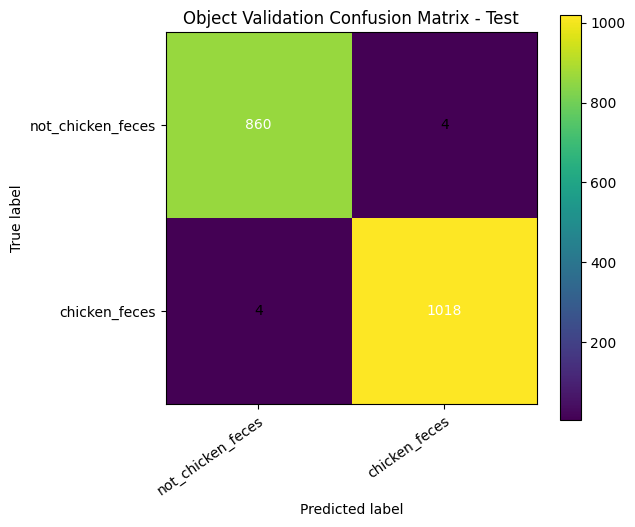

Saved best object model to: /kaggle/working/chickpoo_final_outputs/models/best_models/best_object_validation_model.keras


In [12]:
# =========================================================
# 9. SAVE BEST OBJECT VALIDATION MODEL + TEST EVALUATION
# =========================================================
best_object_row = object_results_df.iloc[0]
best_object_model_path = best_object_row["model_path"]
best_object_name = best_object_row["model_name"]
print("Best object validation model:", best_object_name)

best_object_model = tf.keras.models.load_model(best_object_model_path)

val_result, y_val_true, y_val_pred, y_val_prob = evaluate_binary_model(best_object_model, object_val_ds, split_name="val")
best_threshold = val_result["threshold"]
test_result, y_test_true, y_test_pred, y_test_prob = evaluate_binary_model(best_object_model, object_test_ds, split_name="test", threshold=best_threshold)

print("Best threshold:", best_threshold)
print("Test result:", test_result)
print("\nClassification report - Object Validation Test")
print(classification_report(y_test_true, y_test_pred, target_names=OBJECT_CLASSES, zero_division=0))

cm_object = confusion_matrix(y_test_true, y_test_pred)
plot_confusion_matrix(
    cm_object,
    OBJECT_CLASSES,
    "Object Validation Confusion Matrix - Test",
    f"{OUTPUT_DIR}/plots/object_validation/best_object_validation_confusion_matrix.png",
)

best_object_final_path = f"{OUTPUT_DIR}/models/best_models/best_object_validation_model.keras"
best_object_model.save(best_object_final_path)

object_metadata = {
    "task": "object_validation",
    "class_names": OBJECT_CLASSES,
    "positive_class": "chicken_feces",
    "img_size": IMG_SIZE,
    "threshold": best_threshold,
    "best_model_name": best_object_name,
    "best_model_path": best_object_final_path,
    "val_metrics": val_result,
    "test_metrics": test_result,
    "created_at": datetime.now().isoformat(),
}
save_json(object_metadata, f"{OUTPUT_DIR}/metadata/object_validation_metadata.json")

pd.DataFrame([val_result, test_result]).to_csv(f"{OUTPUT_DIR}/reports/object_validation/best_object_validation_metrics.csv", index=False)
print("Saved best object model to:", best_object_final_path)


# Part 2 — Disease Classification Model

In [15]:
# =========================================================
# 10. DISEASE CLASSIFICATION DATASET
# =========================================================
disease_df = build_disease_dataframe(CHICKPOO_DATASET_DIR)
print("Disease classification total images:", len(disease_df))
print(disease_df["label"].value_counts())

disease_train_df, disease_val_df, disease_test_df = stratified_split(disease_df)
disease_train_balanced_df = balance_train_dataframe(
    disease_train_df,
    max_per_class=MAX_DISEASE_TRAIN_PER_CLASS,
)

print("\nTrain before balance:")
print(disease_train_df["label"].value_counts())
print("\nTrain after balance:")
print(disease_train_balanced_df["label"].value_counts())
print("\nValidation:")
print(disease_val_df["label"].value_counts())
print("\nTest:")
print(disease_test_df["label"].value_counts())

disease_train_paths = disease_train_balanced_df["filepath"].values
disease_val_paths = disease_val_df["filepath"].values
disease_test_paths = disease_test_df["filepath"].values

disease_train_y = encode_labels(disease_train_balanced_df, DISEASE_CLASSES)
disease_val_y = encode_labels(disease_val_df, DISEASE_CLASSES)
disease_test_y = encode_labels(disease_test_df, DISEASE_CLASSES)

disease_train_ds = make_dataset(disease_train_paths, disease_train_y, task="multiclass", shuffle=True)
disease_val_ds = make_dataset(disease_val_paths, disease_val_y, task="multiclass", shuffle=False)
disease_test_ds = make_dataset(disease_test_paths, disease_test_y, task="multiclass", shuffle=False)


Disease classification total images: 6812
label
salmo      2276
cocci      2103
healthy    2057
ncd         376
Name: count, dtype: int64

Train before balance:
label
salmo      1593
cocci      1472
healthy    1440
ncd         263
Name: count, dtype: int64

Train after balance:
label
healthy    1593
ncd        1593
salmo      1593
cocci      1593
Name: count, dtype: int64

Validation:
label
salmo      342
cocci      315
healthy    309
ncd         56
Name: count, dtype: int64

Test:
label
salmo      341
cocci      316
healthy    308
ncd         57
Name: count, dtype: int64


In [16]:
# =========================================================
# 11. DISEASE CLASSIFICATION TRAINING + HYPERPARAMETER TUNING
# =========================================================
disease_results = []
disease_model_records = []

DISEASE_TRIALS = [
    {"backbone": "mobilenetv2", "dense_units": 128, "dropout": 0.30, "lr": 1e-3, "augmentation": "medium", "fine_lr": 1e-5, "unfreeze_ratio": 0.20},
    {"backbone": "mobilenetv2", "dense_units": 256, "dropout": 0.45, "lr": 3e-4, "augmentation": "strong", "fine_lr": 5e-6, "unfreeze_ratio": 0.25},
    {"backbone": "resnet50v2", "dense_units": 256, "dropout": 0.45, "lr": 3e-4, "augmentation": "medium", "fine_lr": 5e-6, "unfreeze_ratio": 0.20},
    {"backbone": "efficientnetb0", "dense_units": 128, "dropout": 0.30, "lr": 1e-3, "augmentation": "medium", "fine_lr": 1e-5, "unfreeze_ratio": 0.20},
    {"backbone": "efficientnetb0", "dense_units": 256, "dropout": 0.40, "lr": 3e-4, "augmentation": "medium", "fine_lr": 5e-6, "unfreeze_ratio": 0.25},
    {"backbone": "efficientnetb0", "dense_units": 512, "dropout": 0.50, "lr": 1e-4, "augmentation": "strong", "fine_lr": 3e-6, "unfreeze_ratio": 0.30},
]


def train_disease_model(model, model_name, epochs, patience=3):
    weights_path = f"{OUTPUT_DIR}/weights/disease_classification/{model_name}.weights.h5"
    history = model.fit(
        disease_train_ds,
        validation_data=disease_val_ds,
        epochs=epochs,
        callbacks=get_callbacks(weights_path, patience=patience),
        verbose=1,
    )
    if os.path.exists(weights_path):
        model.load_weights(weights_path)
    model_path = f"{OUTPUT_DIR}/models/disease_classification/all_models/{model_name}.keras"
    model.save(model_path)
    save_history(history, f"{OUTPUT_DIR}/reports/disease_classification/{model_name}_history.csv")

    val_result, _, _, _, _ = evaluate_multiclass_model(model, disease_val_ds, DISEASE_CLASSES, split_name="val")
    val_result.update({"model_name": model_name, "model_path": model_path})
    disease_results.append(val_result)
    disease_model_records.append({"model_name": model_name, "model_path": model_path})
    pd.DataFrame(disease_results).to_csv(f"{OUTPUT_DIR}/reports/disease_classification/disease_tuning_results.csv", index=False)
    print("VAL RESULT:", val_result)
    return model, val_result

if RUN_SIMPLE_CNN_BASELINE:
    tf.keras.backend.clear_session()
    model = build_simple_cnn(
        task="multiclass",
        class_count=len(DISEASE_CLASSES),
        dense_units=256,
        dropout=0.45,
        lr=1e-3,
        augmentation="medium",
    )
    model, _ = train_disease_model(model, "disease_simple_cnn_baseline", BASELINE_EPOCHS)
    del model

if RUN_TRANSFER_TUNING:
    for i, hp in enumerate(DISEASE_TRIALS, start=1):
        tf.keras.backend.clear_session()
        model_name = (
            f"disease_trial_{i}_{hp['backbone']}_du{hp['dense_units']}_"
            f"do{str(hp['dropout']).replace('.', '')}_lr{hp['lr']}_aug{hp['augmentation']}"
        )
        print("\n", "="*90)
        print("Training", model_name)
        print(hp)
        model = build_transfer_model(
            backbone_key=hp["backbone"],
            task="multiclass",
            class_count=len(DISEASE_CLASSES),
            dense_units=hp["dense_units"],
            dropout=hp["dropout"],
            lr=hp["lr"],
            augmentation=hp["augmentation"],
        )
        model, _ = train_disease_model(model, model_name, TUNING_EPOCHS)
        del model

disease_results_df = pd.DataFrame(disease_results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(disease_results_df)


Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 87s 417ms/step - accuracy: 0.7519 - loss: 0.6465 - val_accuracy: 0.5196 - val_loss: 1.2629 - learning_rate: 0.0010
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 404ms/step - accuracy: 0.8318 - loss: 0.4496 - val_accuracy: 0.6585 - val_loss: 0.8322 - learning_rate: 0.0010
Epoch 3/8
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8600 - loss: 0.3857
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00035000001662410796.
200/200 ━━━━━━━━━━━━━━━━━━━━ 86s 429ms/step - accuracy: 0.8635 - loss: 0.3756 - val_accuracy: 0.6164 - val_loss: 2.4237 - learning_rate: 0.0010
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.8978 - loss: 0.2904 - val_accuracy: 0.9002 - val_loss: 0.2889 - learning_rate: 3.5000e-04
Epoch 5/8
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9176 - loss: 0.2435
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00012250000581843777.
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.9157

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


200/200 ━━━━━━━━━━━━━━━━━━━━ 131s 656ms/step - accuracy: 0.9490 - loss: 0.1439 - val_accuracy: 0.9452 - val_loss: 0.1809 - learning_rate: 3.5000e-04
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 410ms/step - accuracy: 0.9575 - loss: 0.1235 - val_accuracy: 0.9452 - val_loss: 0.1789 - learning_rate: 3.5000e-04
Epoch 5/8
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9603 - loss: 0.1149
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00012250000581843777.
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.9614 - loss: 0.1151 - val_accuracy: 0.9344 - val_loss: 0.1933 - learning_rate: 3.5000e-04
Epoch 6/8
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9655 - loss: 0.1073
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.287500050850212e-05.
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 403ms/step - accuracy: 0.9642 - loss: 0.1073 - val_accuracy: 0.9393 - val_loss: 0.1811 - learning_rate: 1.2250e-04
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.96

E0000 00:00:1783186559.828913      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_multiclass_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 95s 426ms/step - accuracy: 0.8931 - loss: 0.2994 - val_accuracy: 0.9540 - val_loss: 0.1400 - learning_rate: 0.0010
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 142s 709ms/step - accuracy: 0.9413 - loss: 0.1688 - val_accuracy: 0.9658 - val_loss: 0.1301 - learning_rate: 0.0010
Epoch 3/8
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9601 - loss: 0.1115
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00035000001662410796.
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 418ms/step - accuracy: 0.9583 - loss: 0.1153 - val_accuracy: 0.9609 - val_loss: 0.1430 - learning_rate: 0.0010
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 86s 428ms/step - accuracy: 0.9688 - loss: 0.0922 - val_accuracy: 0.9667 - val_loss: 0.1251 - learning_rate: 3.5000e-04
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 85s 426ms/step - accuracy: 0.9719 - loss: 0.0863 - val_accuracy: 0.9677 - val_loss: 0.1234 - learning_rate: 3.5000e-04
Epoch 6/8
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9711 - los

...

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.9695 - loss: 0.0994
Epoch 7: ReduceLROnPlateau reducing learning rate to 1.2862501171184703e-05.
200/200 ━━━━━━━━━━━━━━━━━━━━ 117s 584ms/step - accuracy: 0.9692 - loss: 0.0918 - val_accuracy: 0.9697 - val_loss: 0.1034 - learning_rate: 3.6750e-05
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
VAL RESULT: {'split': 'val', 'accuracy': 0.9686888454011742, 'macro_precision': 0.9548097402191356, 'macro_recall': 0.9381196721577406, 'macro_f1': 0.9459601837070545, 'weighted_f1': 0.9683661073165227, 'model_name': 'disease_trial_5_efficientnetb0_du256_do04_lr0.0003_augmedium', 'model_path': '/kaggle/working/chickpoo_final_outputs/models/disease_classification/all_models/disease_trial_5_efficientnetb0_du256_do04_lr0.0003_augmedium.keras'}

Training disease_trial_6_efficientnetb0_du512_do05_lr0.0001_augstrong
{'backbone': 'efficientnetb0', 'dense_units': 512, 'dropout': 0.5, 'lr': 0.0001, 'augmentation': '

E0000 00:00:1783187970.874059      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_multiclass_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 95s 424ms/step - accuracy: 0.7781 - loss: 0.6154 - val_accuracy: 0.9315 - val_loss: 0.2393 - learning_rate: 1.0000e-04
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 401ms/step - accuracy: 0.8879 - loss: 0.3119 - val_accuracy: 0.9501 - val_loss: 0.1489 - learning_rate: 1.0000e-04
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.9121 - loss: 0.2548 - val_accuracy: 0.9618 - val_loss: 0.1285 - learning_rate: 1.0000e-04
Epoch 4/8
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9338 - loss: 0.1964
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.499999911582563e-05.
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.9298 - loss: 0.2048 - val_accuracy: 0.9609 - val_loss: 0.1285 - learning_rate: 1.0000e-04
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 406ms/step - accuracy: 0.9363 - loss: 0.1838 - val_accuracy: 0.9628 - val_loss: 0.1259 - learning_rate: 3.5000e-05
Epoch 6/8
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.

,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,model_name,model_path
0,val,0.968689,0.954810,0.938120,0.945960,0.968366,disease_trial_5_efficientnetb0_du256_do04_lr0....,/kaggle/working/chickpoo_final_outputs/models/...
1,val,0.967710,0.954176,0.937389,0.945281,0.967424,disease_trial_4_efficientnetb0_du128_do03_lr0....,/kaggle/working/chickpoo_final_outputs/models/...
2,val,0.961840,0.948294,0.921584,0.933643,0.961302,disease_trial_6_efficientnetb0_du512_do05_lr0....,/kaggle/working/chickpoo_final_outputs/models/...
3,val,0.951076,0.919247,0.902358,0.910116,0.950568,disease_trial_2_mobilenetv2_du256_do045_lr0.00...,/kaggle/working/chickpoo_final_outputs/models/...
4,val,0.943249,0.896533,0.896181,0.896233,0.943403,disease_trial_1_mobilenetv2_du128_do03_lr0.001...,/kaggle/working/chickpoo_final_outputs/models/...
5,val,0.933464,0.879987,0.866223,0.872578,0.932589,disease_trial_3_resnet50v2_du256_do045_lr0.000...,/kaggle/working/chickpoo_final_outputs/models/...
6,val,0.900196,0.864526,0.822607,0.837770,0.898317,disease_simple_cnn_baseline,/kaggle/working/chickpoo_final_outputs/models/...


In [18]:
# =========================================================
# REPLACE fine_tune_model - SAFE FOR BINARY & SPARSE MULTICLASS
# =========================================================

import re
import tensorflow as tf

def find_backbone_layer(model, backbone_key):
    """
    Mencari backbone layer secara fleksibel.
    Aman untuk layer bernama:
    - backbone_efficientnetb0
    - efficientnetb0
    - mobilenetv2
    - resnet50v2
    """
    backbone_key_norm = backbone_key.lower().replace("_", "").replace("-", "")
    
    keyword_map = {
        "mobilenetv2": ["mobilenetv2", "mobilenet"],
        "resnet50v2": ["resnet50v2", "resnet"],
        "efficientnetb0": ["efficientnetb0", "efficientnet"],
    }
    
    keywords = keyword_map.get(backbone_key_norm, [backbone_key_norm])
    
    for layer in model.layers:
        layer_name_norm = layer.name.lower().replace("_", "").replace("-", "")
        
        if layer_name_norm == f"backbone{backbone_key_norm}":
            return layer
        
        if layer_name_norm == backbone_key_norm:
            return layer
        
        for kw in keywords:
            kw_norm = kw.lower().replace("_", "").replace("-", "")
            if kw_norm in layer_name_norm:
                return layer
    
    nested_candidates = []
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            if "augmentation" not in layer.name.lower():
                nested_candidates.append(layer)
    
    if len(nested_candidates) > 0:
        print("Backbone layer ditemukan via fallback:", nested_candidates[0].name)
        return nested_candidates[0]
    
    raise ValueError(
        f"Backbone layer tidak ditemukan. Existing layers: {[layer.name for layer in model.layers]}"
    )


def fine_tune_model(model, backbone_key, lr=1e-5, unfreeze_ratio=0.25, task="binary", class_count=2):
    """
    Fine-tuning model.
    Binary task  : binary_crossentropy
    Multiclass   : sparse_categorical_crossentropy karena label dataset berbentuk integer.
    """
    backbone = find_backbone_layer(model, backbone_key)
    
    print("Backbone selected for fine-tuning:", backbone.name)
    
    backbone.trainable = True
    
    total_layers = len(backbone.layers)
    fine_tune_at = int(total_layers * (1 - unfreeze_ratio))
    
    for layer in backbone.layers[:fine_tune_at]:
        layer.trainable = False
        
    for layer in backbone.layers[fine_tune_at:]:
        layer.trainable = True
    
    print(f"Total backbone layers     : {total_layers}")
    print(f"Frozen layers             : {fine_tune_at}")
    print(f"Trainable backbone layers : {total_layers - fine_tune_at}")
    
    if task == "binary":
        loss = "binary_crossentropy"
        metrics = [
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
        
    elif task in ["multiclass", "sparse_multiclass"]:
        loss = "sparse_categorical_crossentropy"
        metrics = ["accuracy"]
        
    else:
        raise ValueError("task harus 'binary' atau 'multiclass'")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=metrics
    )
    
    return model

In [19]:
# =========================================================
# 12. DISEASE CLASSIFICATION FINE-TUNING BEST TRANSFER MODEL
# =========================================================

if RUN_FINE_TUNING and RUN_TRANSFER_TUNING:
    transfer_rows = disease_results_df[
        disease_results_df["model_name"].str.contains("disease_trial", na=False)
    ].copy()
    
    if len(transfer_rows) > 0:
        best_transfer_row = transfer_rows.iloc[0]
        best_transfer_name = best_transfer_row["model_name"]
        
        trial_match = re.search(r"disease_trial_(\d+)", best_transfer_name)
        
        if trial_match is None:
            raise ValueError(f"Tidak bisa membaca nomor trial dari model_name: {best_transfer_name}")
        
        best_trial_idx = int(trial_match.group(1)) - 1
        best_hp = DISEASE_TRIALS[best_trial_idx]
        
        print("Best disease transfer model:", best_transfer_name)
        print("Best HP:", best_hp)
        print("Loading model from:", best_transfer_row["model_path"])
        
        tf.keras.backend.clear_session()
        
        model = tf.keras.models.load_model(
            best_transfer_row["model_path"],
            compile=False
        )
        
        model = fine_tune_model(
            model,
            backbone_key=best_hp["backbone"],
            lr=best_hp["fine_lr"],
            unfreeze_ratio=best_hp["unfreeze_ratio"],
            task="multiclass",
            class_count=len(DISEASE_CLASSES),
        )
        
        ft_name = f"disease_finetuned_{best_transfer_name}"
        
        model, _ = train_disease_model(
            model,
            ft_name,
            FINE_TUNE_EPOCHS,
            patience=2
        )
        
        del model
        
    else:
        print("Tidak ada transfer learning model disease untuk di-fine-tune.")

disease_results_df = (
    pd.DataFrame(disease_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

disease_results_df.to_csv(
    f"{OUTPUT_DIR}/reports/disease_classification/disease_final_results.csv",
    index=False
)

display(disease_results_df)

Best disease transfer model: disease_trial_5_efficientnetb0_du256_do04_lr0.0003_augmedium
Best HP: {'backbone': 'efficientnetb0', 'dense_units': 256, 'dropout': 0.4, 'lr': 0.0003, 'augmentation': 'medium', 'fine_lr': 5e-06, 'unfreeze_ratio': 0.25}
Loading model from: /kaggle/working/chickpoo_final_outputs/models/disease_classification/all_models/disease_trial_5_efficientnetb0_du256_do04_lr0.0003_augmedium.keras
Backbone selected for fine-tuning: efficientnetb0
Total backbone layers     : 238
Frozen layers             : 178
Trainable backbone layers : 60
Epoch 1/6


E0000 00:00:1783189238.709302      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_multiclass_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 105s 439ms/step - accuracy: 0.8478 - loss: 0.4162 - val_accuracy: 0.9247 - val_loss: 0.2201 - learning_rate: 5.0000e-06
Epoch 2/6
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.8718 - loss: 0.3415
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.7499999557912814e-06.
200/200 ━━━━━━━━━━━━━━━━━━━━ 85s 423ms/step - accuracy: 0.8782 - loss: 0.3225 - val_accuracy: 0.9217 - val_loss: 0.2541 - learning_rate: 5.0000e-06
Epoch 3/6
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8925 - loss: 0.3056
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.124999686107912e-07.
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 407ms/step - accuracy: 0.8952 - loss: 0.2984 - val_accuracy: 0.9178 - val_loss: 0.2551 - learning_rate: 1.7500e-06
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
VAL RESULT: {'split': 'val', 'accuracy': 0.9246575342465754, 'macro_precision': 0.9009338385626373, 'macro_recall': 0.8841846221540908, 'macro_f1

,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,model_name,model_path
0,val,0.968689,0.954810,0.938120,0.945960,0.968366,disease_trial_5_efficientnetb0_du256_do04_lr0....,/kaggle/working/chickpoo_final_outputs/models/...
1,val,0.967710,0.954176,0.937389,0.945281,0.967424,disease_trial_4_efficientnetb0_du128_do03_lr0....,/kaggle/working/chickpoo_final_outputs/models/...
2,val,0.961840,0.948294,0.921584,0.933643,0.961302,disease_trial_6_efficientnetb0_du512_do05_lr0....,/kaggle/working/chickpoo_final_outputs/models/...
3,val,0.951076,0.919247,0.902358,0.910116,0.950568,disease_trial_2_mobilenetv2_du256_do045_lr0.00...,/kaggle/working/chickpoo_final_outputs/models/...
4,val,0.943249,0.896533,0.896181,0.896233,0.943403,disease_trial_1_mobilenetv2_du128_do03_lr0.001...,/kaggle/working/chickpoo_final_outputs/models/...
5,val,0.924658,0.900934,0.884185,0.891285,0.923741,disease_finetuned_disease_trial_5_efficientnet...,/kaggle/working/chickpoo_final_outputs/models/...
6,val,0.933464,0.879987,0.866223,0.872578,0.932589,disease_trial_3_resnet50v2_du256_do045_lr0.000...,/kaggle/working/chickpoo_final_outputs/models/...
7,val,0.900196,0.864526,0.822607,0.837770,0.898317,disease_simple_cnn_baseline,/kaggle/working/chickpoo_final_outputs/models/...


Best disease classification model: disease_trial_5_efficientnetb0_du256_do04_lr0.0003_augmedium
Test result: {'split': 'test', 'accuracy': 0.9784735812133072, 'macro_precision': 0.9755470138636261, 'macro_recall': 0.9720895293376542, 'macro_f1': 0.9737964507529888, 'weighted_f1': 0.9784476699514488}

Classification report - Disease Classification Test
              precision    recall  f1-score   support

       cocci       0.99      0.99      0.99       316
     healthy       0.97      0.97      0.97       308
         ncd       0.96      0.95      0.96        57
       salmo       0.98      0.98      0.98       341

    accuracy                           0.98      1022
   macro avg       0.98      0.97      0.97      1022
weighted avg       0.98      0.98      0.98      1022



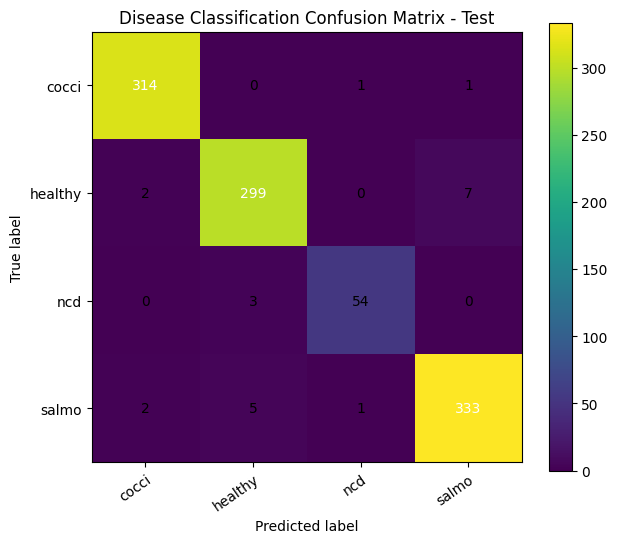

Saved best disease classifier model to: /kaggle/working/chickpoo_final_outputs/models/best_models/best_disease_classifier_model.keras


In [20]:
# =========================================================
# 13. SAVE BEST DISEASE CLASSIFIER MODEL + TEST EVALUATION
# =========================================================
best_disease_row = disease_results_df.iloc[0]
best_disease_model_path = best_disease_row["model_path"]
best_disease_name = best_disease_row["model_name"]
print("Best disease classification model:", best_disease_name)

best_disease_model = tf.keras.models.load_model(best_disease_model_path)

test_result_disease, y_test_true_disease, y_test_pred_disease, y_test_prob_disease, test_report_disease = evaluate_multiclass_model(
    best_disease_model,
    disease_test_ds,
    DISEASE_CLASSES,
    split_name="test",
)

print("Test result:", test_result_disease)
print("\nClassification report - Disease Classification Test")
print(classification_report(y_test_true_disease, y_test_pred_disease, target_names=DISEASE_CLASSES, zero_division=0))

cm_disease = confusion_matrix(y_test_true_disease, y_test_pred_disease)
plot_confusion_matrix(
    cm_disease,
    DISEASE_CLASSES,
    "Disease Classification Confusion Matrix - Test",
    f"{OUTPUT_DIR}/plots/disease_classification/best_disease_confusion_matrix.png",
)

best_disease_final_path = f"{OUTPUT_DIR}/models/best_models/best_disease_classifier_model.keras"
best_disease_model.save(best_disease_final_path)

disease_metadata = {
    "task": "disease_classification",
    "class_names": DISEASE_CLASSES,
    "img_size": IMG_SIZE,
    "best_model_name": best_disease_name,
    "best_model_path": best_disease_final_path,
    "test_metrics": test_result_disease,
    "created_at": datetime.now().isoformat(),
}
save_json(disease_metadata, f"{OUTPUT_DIR}/metadata/disease_classifier_metadata.json")

pd.DataFrame([test_result_disease]).to_csv(f"{OUTPUT_DIR}/reports/disease_classification/best_disease_classifier_metrics.csv", index=False)
with open(f"{OUTPUT_DIR}/reports/disease_classification/best_disease_classifier_report.json", "w") as f:
    json.dump(test_report_disease, f, indent=2)

print("Saved best disease classifier model to:", best_disease_final_path)


# Final Pipeline Inference

In [23]:
# =========================================================
# 14. FINAL TWO-STAGE PREDICTION FUNCTION
# =========================================================
RECOMMENDATION_MAP = {
    "healthy": "Pola visual mendekati kondisi normal. Tetap pantau kondisi ayam, jaga litter kering, dan ulangi scan jika ada perubahan.",
    "cocci": "Terdeteksi menyerupai coccidiosis. Pisahkan ayam yang dicurigai, jaga kandang tetap kering, dan konsultasikan dengan petugas kesehatan hewan.",
    "salmo": "Terdeteksi menyerupai salmonella. Perhatikan kebersihan kandang, pakan, dan air minum. Lakukan pemeriksaan lanjutan bila gejala muncul.",
    "ncd": "Terdeteksi menyerupai Newcastle disease. Segera pisahkan ayam yang dicurigai dan hubungi petugas kesehatan hewan karena penyakit ini berisiko menular.",
}


def preprocess_single_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return tf.expand_dims(img, axis=0)


def predict_chickpoo_pipeline(img_path, object_model, disease_model, object_threshold, show_image=True):
    x = preprocess_single_image(img_path)
    object_prob = float(object_model.predict(x, verbose=0).reshape(-1)[0])
    is_chicken_feces = object_prob >= object_threshold

    result = {
        "image_path": img_path,
        "object_validation": {
            "predicted_class": "chicken_feces" if is_chicken_feces else "not_chicken_feces",
            "chicken_feces_probability": object_prob,
            "threshold": object_threshold,
        },
        "disease_prediction": None,
        "recommendation": None,
    }

    if show_image:
        img_show = plt.imread(img_path)
        plt.figure(figsize=(5, 5))
        plt.imshow(img_show)
        plt.axis("off")
        plt.show()

    if not is_chicken_feces:
        result["recommendation"] = "Objek belum terdeteksi sebagai feses ayam. Silakan unggah foto feses ayam yang lebih jelas."
        return result

    disease_probs = disease_model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(disease_probs))
    pred_class = DISEASE_CLASSES[pred_idx]
    result["disease_prediction"] = {
        "predicted_class": pred_class,
        "confidence": float(disease_probs[pred_idx]),
        "all_probabilities": {cls: float(prob) for cls, prob in zip(DISEASE_CLASSES, disease_probs)},
    }
    result["recommendation"] = RECOMMENDATION_MAP[pred_class]
    return result

# Contoh penggunaan:
# sample_path = disease_test_df.sample(1, random_state=SEED)["filepath"].values[0]
# result = predict_chickpoo_pipeline(sample_path, best_object_model, best_disease_model, best_threshold)
# print(json.dumps(result, indent=2))


In [24]:
# =========================================================
# 15. SAVE SUMMARY + ZIP OUTPUTS
# =========================================================
final_summary = {
    "object_validation": {
        "best_model": best_object_name,
        "best_model_path": best_object_final_path,
        "threshold": best_threshold,
        "test_metrics": test_result,
    },
    "disease_classification": {
        "best_model": best_disease_name,
        "best_model_path": best_disease_final_path,
        "test_metrics": test_result_disease,
    },
    "dataset_paths": {
        "chickpoo_dataset_dir": CHICKPOO_DATASET_DIR,
        "non_feces_dataset_dir": NON_FECES_DATASET_DIR,
    },
    "created_at": datetime.now().isoformat(),
}

save_json(final_summary, f"{OUTPUT_DIR}/metadata/final_training_summary.json")

zip_base = "/kaggle/working/chickpoo_final_outputs_zip"
zip_path = zip_base + ".zip"
if os.path.exists(zip_path):
    os.remove(zip_path)
shutil.make_archive(zip_base, "zip", OUTPUT_DIR)

print("Final outputs folder:", OUTPUT_DIR)
print("ZIP file:", zip_path)
print("ZIP size MB:", round(os.path.getsize(zip_path) / (1024 ** 2), 2))

try:
    from IPython.display import FileLink, display
    os.chdir("/kaggle/working")
    display(FileLink("chickpoo_final_outputs_zip.zip"))
except Exception as e:
    print("FileLink tidak tersedia:", e)


Final outputs folder: /kaggle/working/chickpoo_final_outputs
ZIP file: /kaggle/working/chickpoo_final_outputs_zip.zip
ZIP size MB: 811.31


/kaggle/working/chickpoo_final_outputs_zip.zip